## Imports and Data Loading

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the dataset
file_path = 'BuildbotAnalysis - BuildBots_children_T1T4T7.csv'
df = pd.read_csv(file_path)

# Data Cleaning: Convert 99/999 (missing) to 0
df_clean = df.replace([99, 999], 0)

print(f"Data loaded: {df_clean.shape[0]} rows across {df_clean['Timepoint'].nunique()} timepoints.")
df_clean

Data loaded: 85 rows across 3 timepoints.


,Duration (in seconds),Timepoint,Condition,Participant ID,Group,age,Gender,NAO_safe,NAO_competence,NAO_reliable,...,googled_time_3_TEXT,googled_topics,googled_topics_6_TEXT,friends,friends_time,friends_time_3_TEXT,friends_who,friends_who_4_TEXT,attentioncheck,attentioncheck2
0,1030,T1,Experimental,1,1,13.0,1.0,4,4,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1020,T1,Experimental,2,1,13.0,1.0,7,7,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1205,T1,Experimental,3,2,13.0,1.0,4,6,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1274,T1,Experimental,4,3,12.0,1.0,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1656,T1,Experimental,5,4,14.0,1.0,4,6,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,559,T7,Experimental,28,10,14.0,2.0,4,4,4,...,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,1.0,1.0
81,464,T7,Experimental,29,8,12.0,1.0,1,7,7,...,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,1.0,0.0
82,1061,T7,Experimental,30,9,13.0,2.0,5,6,6,...,NaN,NaN,NaN,1.0,2,NaN,2.0,NaN,1.0,1.0
83,750,T7,Experimental,31,10,13.0,2.0,6,4,5,...,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,1.0,1.0


## Grouping AI Literacy vs. Programming Items

In [7]:
# 1. AI Literacy - Self-Efficacy (MAILS)
mails_cols = [col for col in df.columns if col.startswith('MAILS_')]

# 2. AI Literacy - Knowledge (Knowledge tests)
knowledge_prefixes = ['AI_', 'CA', 'CI', 'UA', 'GA', 'EA', 'LLMdesign']
knowledge_cols = [col for col in df.columns if any(col.startswith(pre) for pre in knowledge_prefixes)]

# 3. Programming Items (PR)
pr_cols = [col for col in df.columns if col.startswith('PR')]

# Calculate aggregate scores (0 to 1 scale if needed, or raw means)
df_clean['AI_SelfEfficacy_Score'] = df_clean[mails_cols].mean(axis=1)
df_clean['AI_Knowledge_Score'] = df_clean[knowledge_cols].mean(axis=1)
df_clean['Programming_PR_Score'] = df_clean[pr_cols].mean(axis=1)

print(f"Grouped {len(mails_cols)} MAILS items, {len(knowledge_cols)} Knowledge items, and {len(pr_cols)} PR items.")
df_clean

Grouped 10 MAILS items, 13 Knowledge items, and 4 PR items.


,Duration (in seconds),Timepoint,Condition,Participant ID,Group,age,Gender,NAO_safe,NAO_competence,NAO_reliable,...,friends,friends_time,friends_time_3_TEXT,friends_who,friends_who_4_TEXT,attentioncheck,attentioncheck2,AI_SelfEfficacy_Score,AI_Knowledge_Score,Programming_PR_Score
0,1030,T1,Experimental,1,1,13.0,1.0,4,4,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.5,0.461538,0.00
1,1020,T1,Experimental,2,1,13.0,1.0,7,7,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.9,0.230769,0.00
2,1205,T1,Experimental,3,2,13.0,1.0,4,6,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.7,0.153846,0.00
3,1274,T1,Experimental,4,3,12.0,1.0,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,0.538462,0.00
4,1656,T1,Experimental,5,4,14.0,1.0,4,6,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.9,0.230769,0.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,559,T7,Experimental,28,10,14.0,2.0,4,4,4,...,2.0,NaN,NaN,NaN,NaN,1.0,1.0,7.1,0.692308,0.25
81,464,T7,Experimental,29,8,12.0,1.0,1,7,7,...,2.0,NaN,NaN,NaN,NaN,1.0,0.0,7.3,0.384615,0.00
82,1061,T7,Experimental,30,9,13.0,2.0,5,6,6,...,1.0,2,NaN,2.0,NaN,1.0,1.0,8.1,0.538462,0.50
83,750,T7,Experimental,31,10,13.0,2.0,6,4,5,...,3.0,NaN,NaN,NaN,NaN,1.0,1.0,7.8,0.307692,0.50


## Visualizing Progression (T1 -> T4 -> T7)

Scores normalized to 0-1 scale.


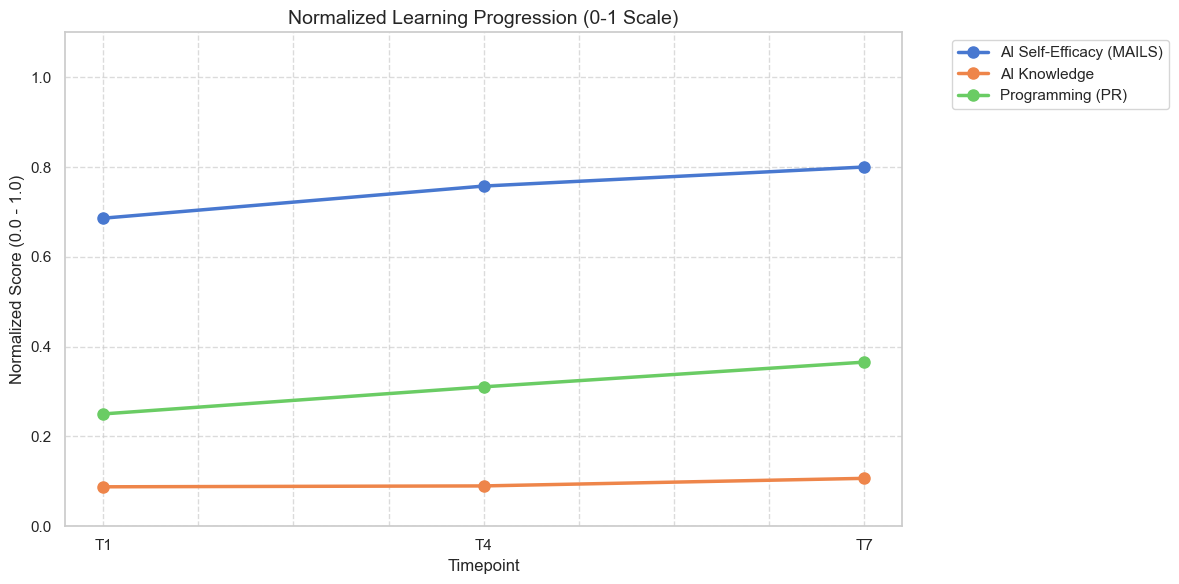

In [9]:
# 1. Identify groups
mails_cols = [col for col in df.columns if col.startswith('MAILS_')]
knowledge_prefixes = ['AI_', 'CA', 'CI', 'UA', 'GA', 'EA', 'LLMdesign']
knowledge_cols = [col for col in df.columns if any(col.startswith(pre) for pre in knowledge_prefixes)]
pr_cols = [col for col in df.columns if col.startswith('PR')]

# 2. Normalize and calculate aggregate scores (0 to 1 scale)
# MAILS usually goes up to 10 or 11
df_clean['AI_SelfEfficacy_Score'] = df_clean[mails_cols].mean(axis=1) / 10.0 

# Knowledge items (often 0/1 or small scales)
# We divide by the max observed value in these columns to normalize
df_clean['AI_Knowledge_Score'] = df_clean[knowledge_cols].mean(axis=1) / df_clean[knowledge_cols].max().max()

# Programming PR items (typically 0 or 1)
df_clean['Programming_PR_Score'] = df_clean[pr_cols].mean(axis=1)

print("Scores normalized to 0-1 scale.")
# Prepare data for plotting
plot_data = df_clean.groupby('Timepoint')[['AI_SelfEfficacy_Score', 'AI_Knowledge_Score', 'Programming_PR_Score']].mean().reindex(['T1', 'T4', 'T7'])

# Plotting
plot_data.plot(kind='line', marker='o', linewidth=2.5, markersize=8)
plt.title('Normalized Learning Progression (0-1 Scale)', fontsize=14)
plt.ylabel('Normalized Score (0.0 - 1.0)', fontsize=12)
plt.xlabel('Timepoint', fontsize=12)
plt.ylim(0, 1.1) # Set Y axis from 0 to 1
plt.legend(['AI Self-Efficacy (MAILS)', 'AI Knowledge', 'Programming (PR)'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Comparing Growth (T1 vs. T7)

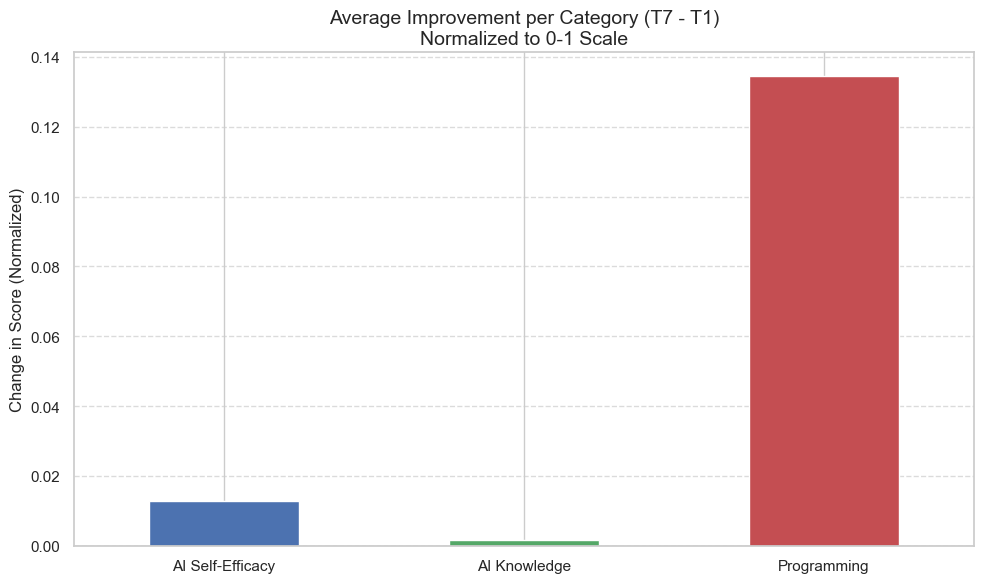

In [12]:
# 1. Calculate Delta (Growth)
growth = (t7_scores - t1_scores).mean()

# 2. Rename the index for the chart
growth.index = ['AI Self-Efficacy', 'AI Knowledge', 'Programming']

# 3. Visualize Comparison
plt.figure(figsize=(10, 6))
colors = ['#4C72B0', '#55A868', '#C44E52']
growth.plot(kind='bar', color=colors)

plt.title('Average Improvement per Category (T7 - T1)\nNormalized to 0-1 Scale', fontsize=14)
plt.ylabel('Change in Score (Normalized)')

# Fix: Only handle rotation here, labels are now automatic from growth.index
plt.xticks(rotation=0) 

plt.axhline(0, color='black', linewidth=0.8)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Looking into individual AI literacy items

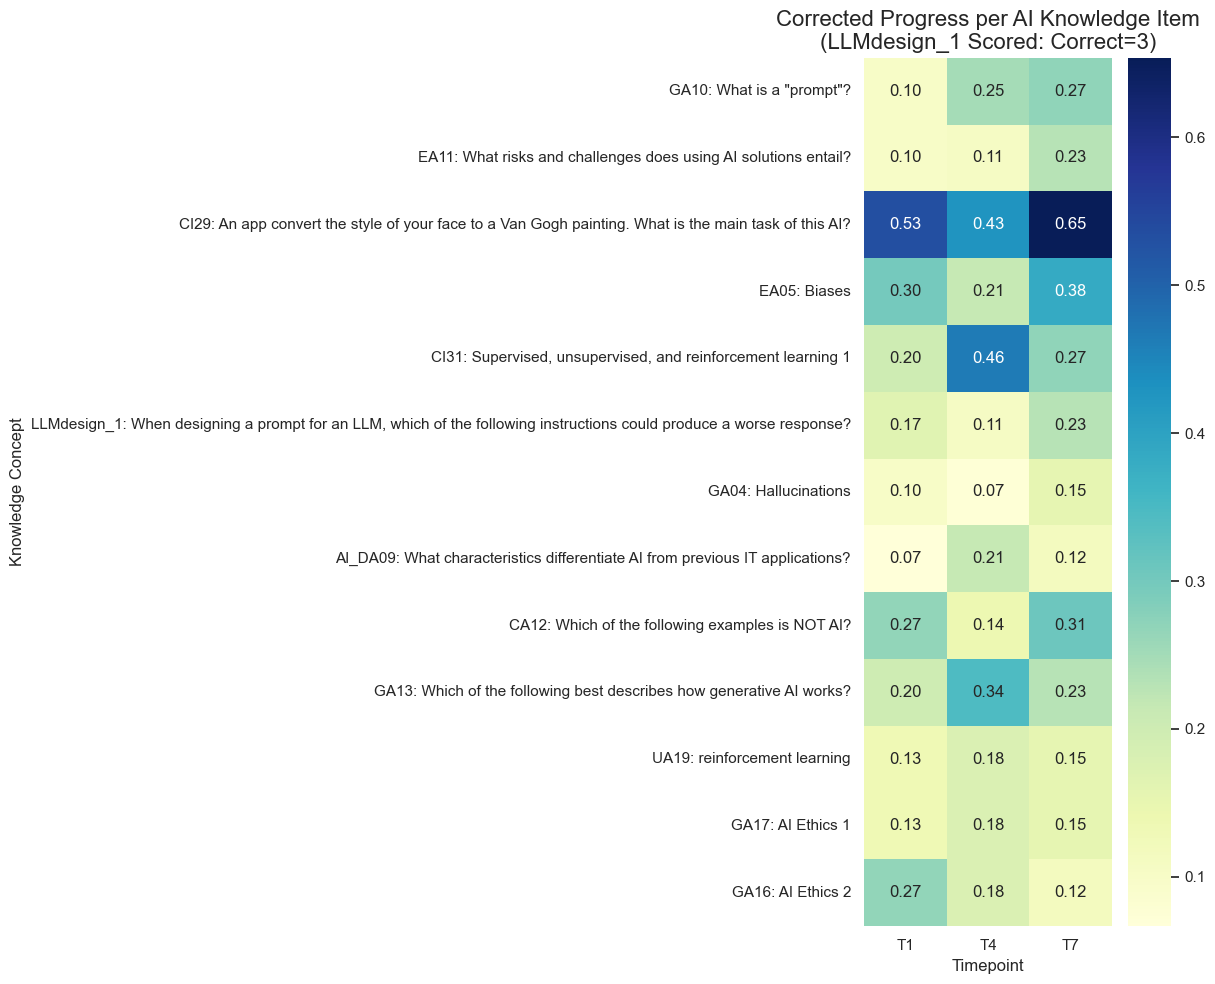

LLMdesign_1 has been re-scored (Answer 3 = 100%).


In [19]:
# 1. Create a scored version of the Knowledge Items
df_scored = df_clean.copy()

# Recode LLMdesign_1: Correct = 1 if answer is 3, else 0
# We use .apply to keep NaNs as NaNs so they don't bias the result
df_scored['LLMdesign_1: When designing a prompt for an LLM, which of the following instructions could produce a worse response?'] = df_scored['LLMdesign_1: When designing a prompt for an LLM, which of the following instructions could produce a worse response?'].apply(
    lambda x: 1 if x == 3 else (0 if pd.notnull(x) else np.nan)
)

# 2. Identify all knowledge columns (including the newly scored one)
knowledge_prefixes = ['AI_', 'CA', 'CI', 'UA', 'GA', 'EA', 'LLMdesign']
knowledge_cols = [col for col in df.columns if any(col.startswith(pre) for pre in knowledge_prefixes)]

# 3. Calculate average per item per timepoint using the SCORED data
item_progress = df_scored.groupby('Timepoint')[knowledge_cols].mean().reindex(['T1', 'T4', 'T7']).T

# Calculate improvement for sorting
item_progress['Improvement'] = item_progress['T7'] - item_progress['T1']
item_progress_sorted = item_progress.sort_values(by='Improvement', ascending=False)

# 4. Visualize the Corrected Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(item_progress_sorted[['T1', 'T4', 'T7']], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title('Corrected Progress per AI Knowledge Item\n(LLMdesign_1 Scored: Correct=3)', fontsize=16)
plt.ylabel('Knowledge Concept', fontsize=12)
plt.xlabel('Timepoint', fontsize=12)
plt.tight_layout()
plt.show()

print("LLMdesign_1 has been re-scored (Answer 3 = 100%).")

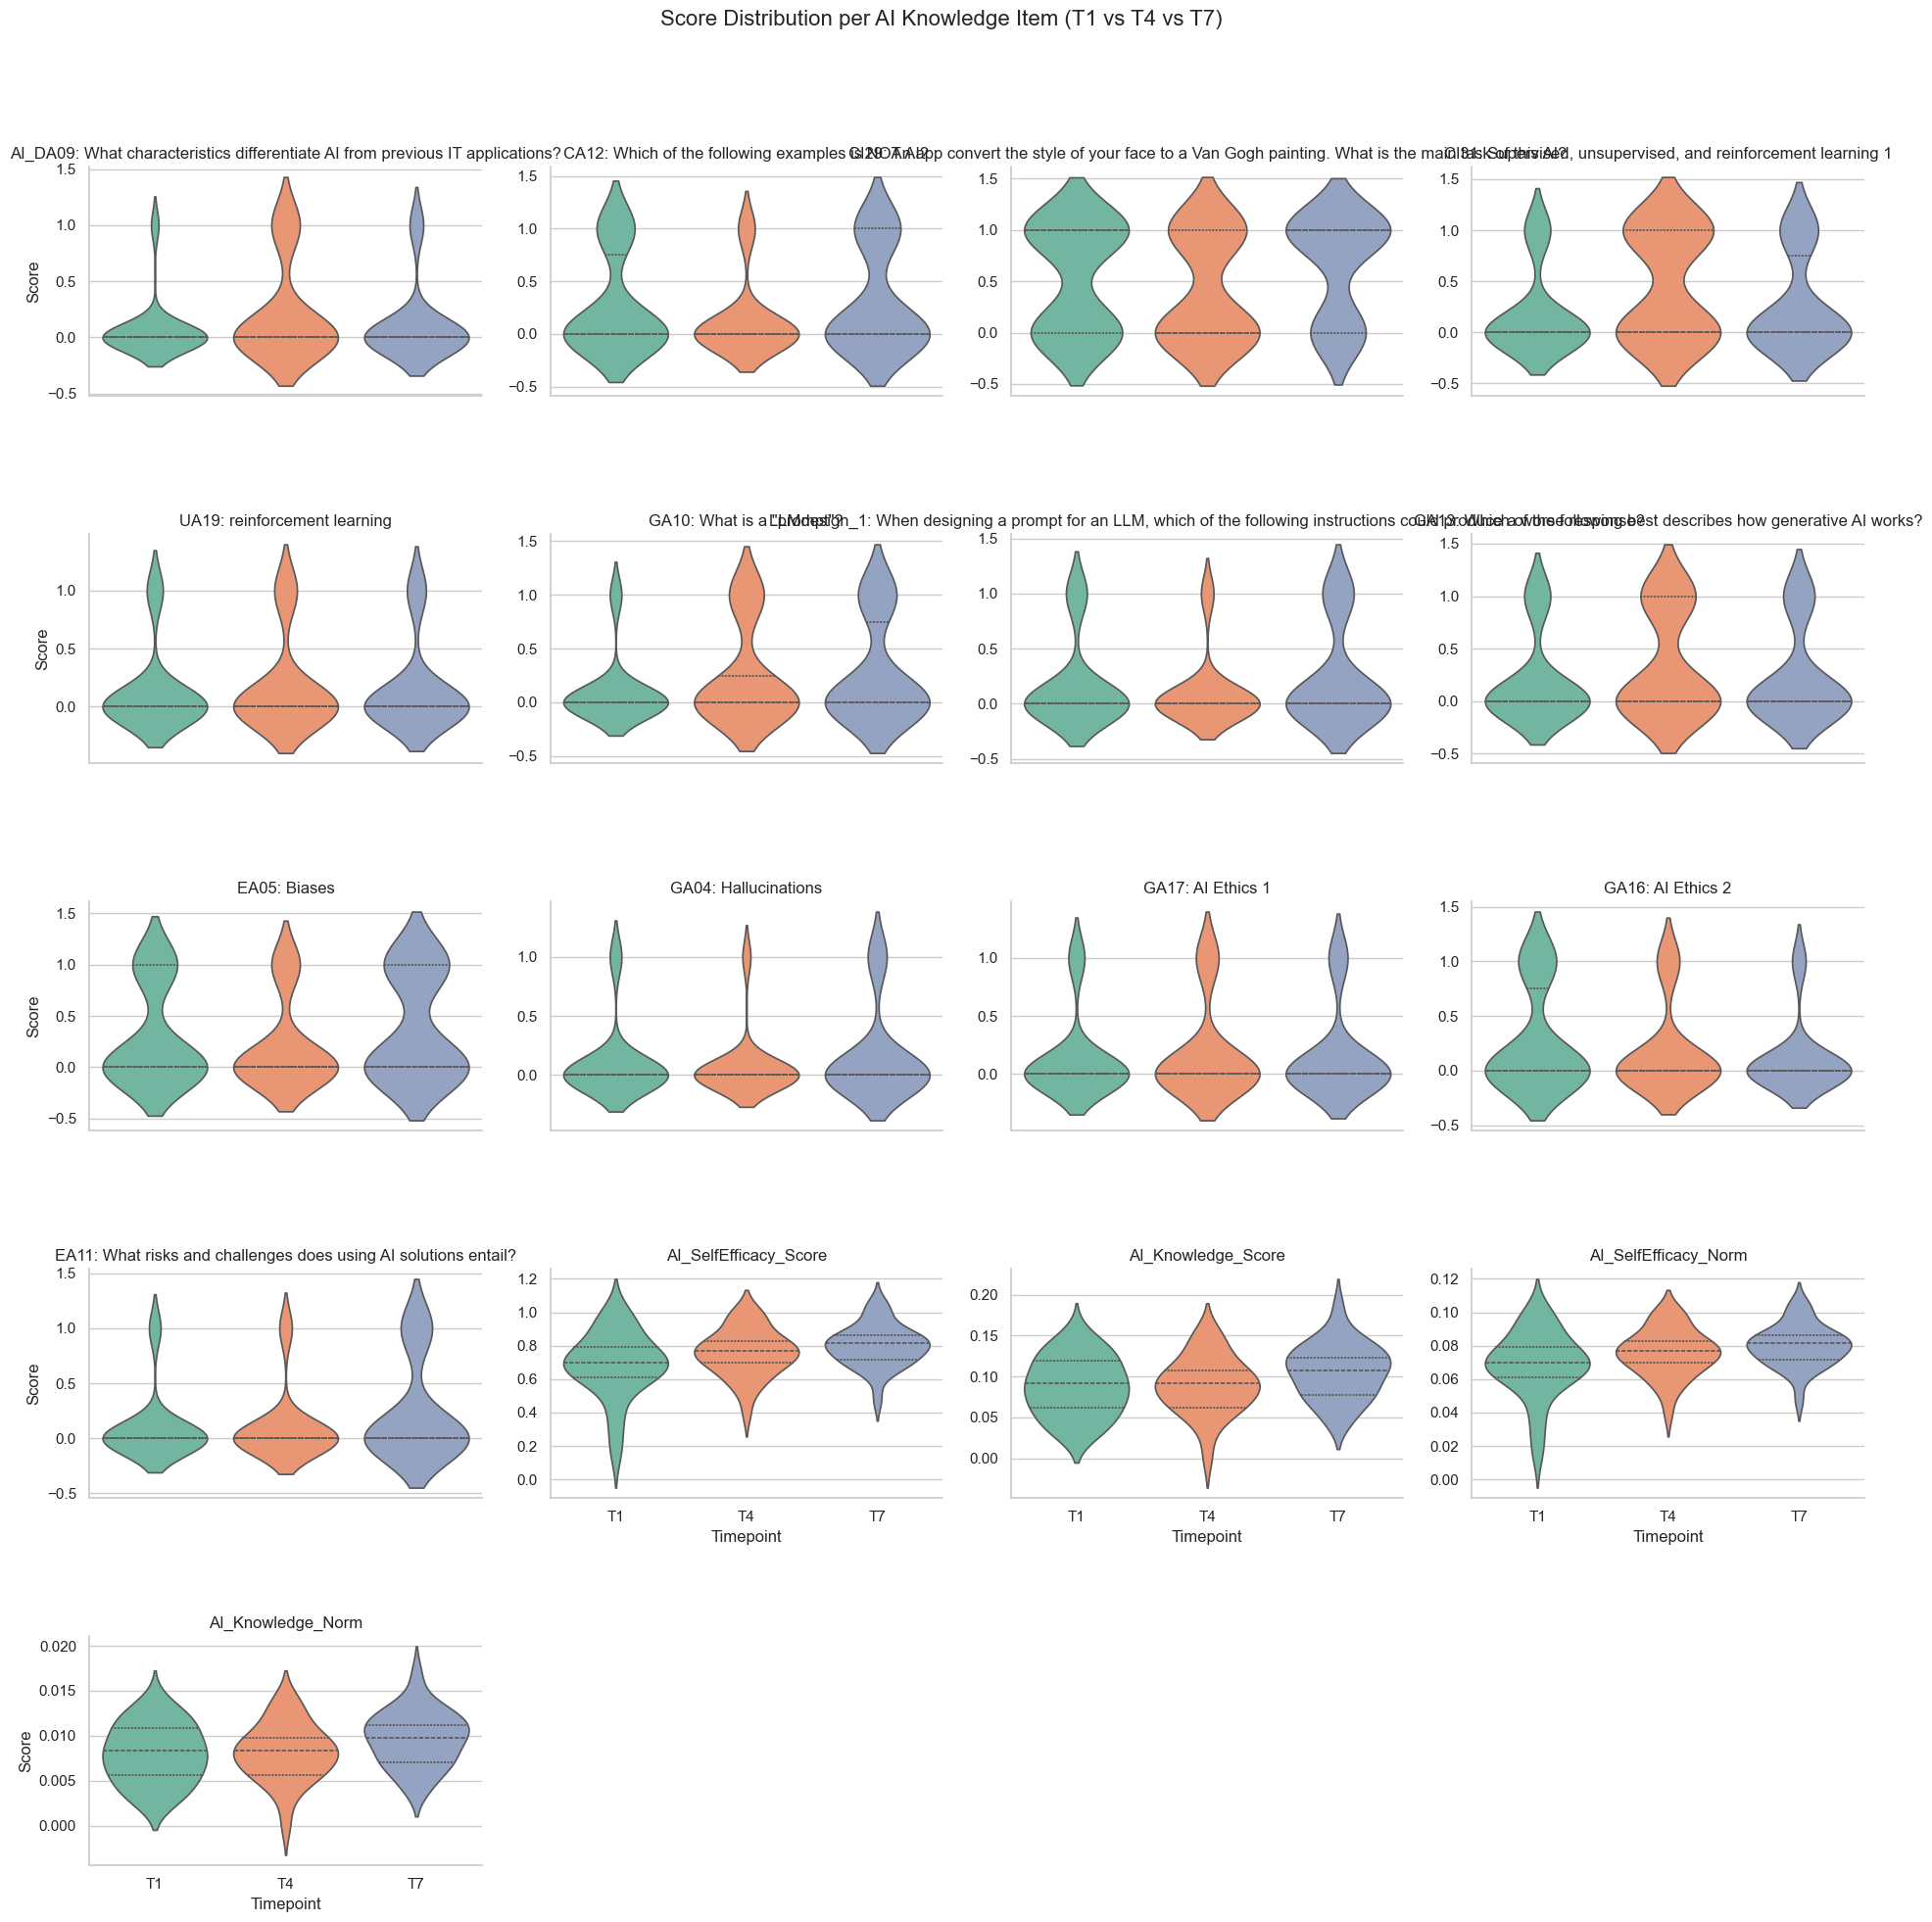

In [22]:
# 1. Reshape data to "long" format for plotting
knowledge_prefixes = ['AI_', 'CA', 'CI', 'UA', 'GA', 'EA', 'LLMdesign']
knowledge_cols = [col for col in df_scored.columns if any(col.startswith(pre) for pre in knowledge_prefixes)]

df_melted = df_scored.melt(
    id_vars=['Timepoint', 'Participant ID'], 
    value_vars=knowledge_cols, 
    var_name='Knowledge_Item', 
    value_name='Score'
)

# Ensure timepoints are in the correct chronological order
df_melted['Timepoint'] = pd.Categorical(df_melted['Timepoint'], categories=['T1', 'T4', 'T7'], ordered=True)

# 2. Create the Violin Plots with the new Seaborn convention
# We use hue="Timepoint" and legend=False to fix the FutureWarning
g = sns.FacetGrid(df_melted, col="Knowledge_Item", col_wrap=4, height=4, aspect=1.2, sharey=False)

# map_dataframe is the more modern way to handle this
g.map_dataframe(
    sns.violinplot, 
    x="Timepoint", 
    y="Score", 
    hue="Timepoint", 
    palette="Set2", 
    inner="quart", 
    legend=False
)

# Improve formatting
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Timepoint", "Score")

# Add a bit of space between subplots
plt.subplots_adjust(top=0.9, hspace=0.6)
g.fig.suptitle('Score Distribution per AI Knowledge Item (T1 vs T4 vs T7)', fontsize=16)

plt.show()

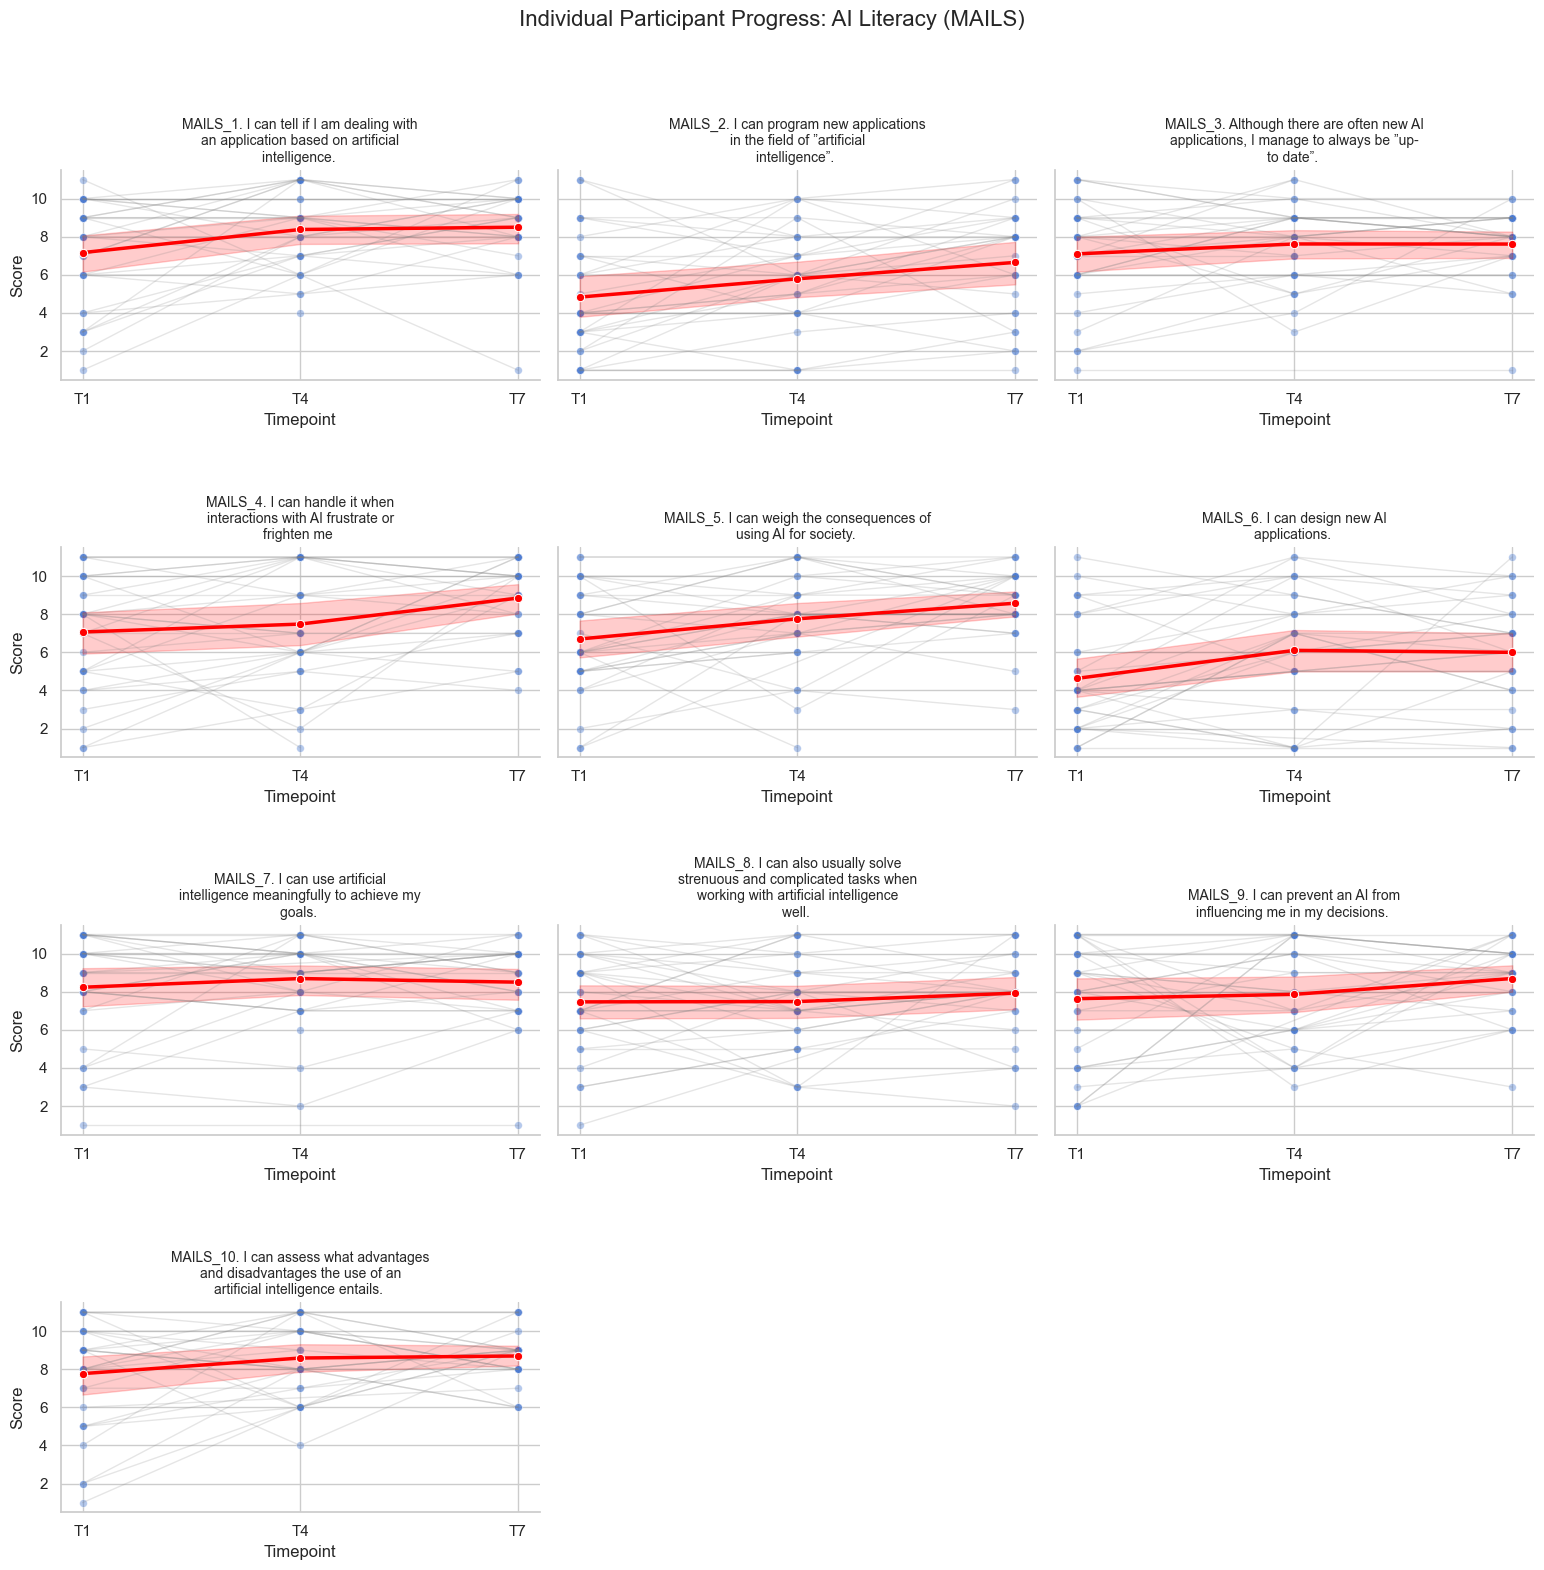

In [24]:
import textwrap

# 1. Prepare the data
mails_cols = [col for col in df_scored.columns if col.startswith('MAILS_')]
df_mails_long = df_scored.melt(
    id_vars=['Timepoint', 'Participant ID'], 
    value_vars=mails_cols, 
    var_name='AI_Literacy_Item', 
    value_name='Score'
)
df_mails_long['Timepoint'] = pd.Categorical(df_mails_long['Timepoint'], categories=['T1', 'T4', 'T7'], ordered=True)

# 2. Create FacetGrid with sharex=False (this shows T1, T4, T7 on every plot)
g = sns.FacetGrid(df_mails_long, col="AI_Literacy_Item", col_wrap=3, height=4, aspect=1.3, sharey=True, sharex=False)

# 3. Map the lines and points
g.map_dataframe(sns.lineplot, x="Timepoint", y="Score", units="Participant ID", estimator=None, color="gray", alpha=0.2, linewidth=1)
g.map_dataframe(sns.scatterplot, x="Timepoint", y="Score", alpha=0.4, s=30)
g.map_dataframe(sns.lineplot, x="Timepoint", y="Score", color="red", linewidth=2.5, marker='o')

# 4. FIX: Wrap titles and force X-labels on every plot
for ax, title in zip(g.axes.flat, df_mails_long['AI_Literacy_Item'].unique()):
    # Wraps the long title every 40 characters
    wrapped_title = "\n".join(textwrap.wrap(title, width=40))
    ax.set_title(wrapped_title, fontsize=10)
    
    # Force the x-axis to show labels and title on every subplot
    ax.tick_params(labelbottom=True)
    ax.set_xlabel('Timepoint')

# 5. Final layout adjustments
plt.subplots_adjust(top=0.88, hspace=0.8) # Increased hspace to give room for multi-line titles
g.fig.suptitle('Individual Participant Progress: AI Literacy (MAILS)', fontsize=16)

plt.show()

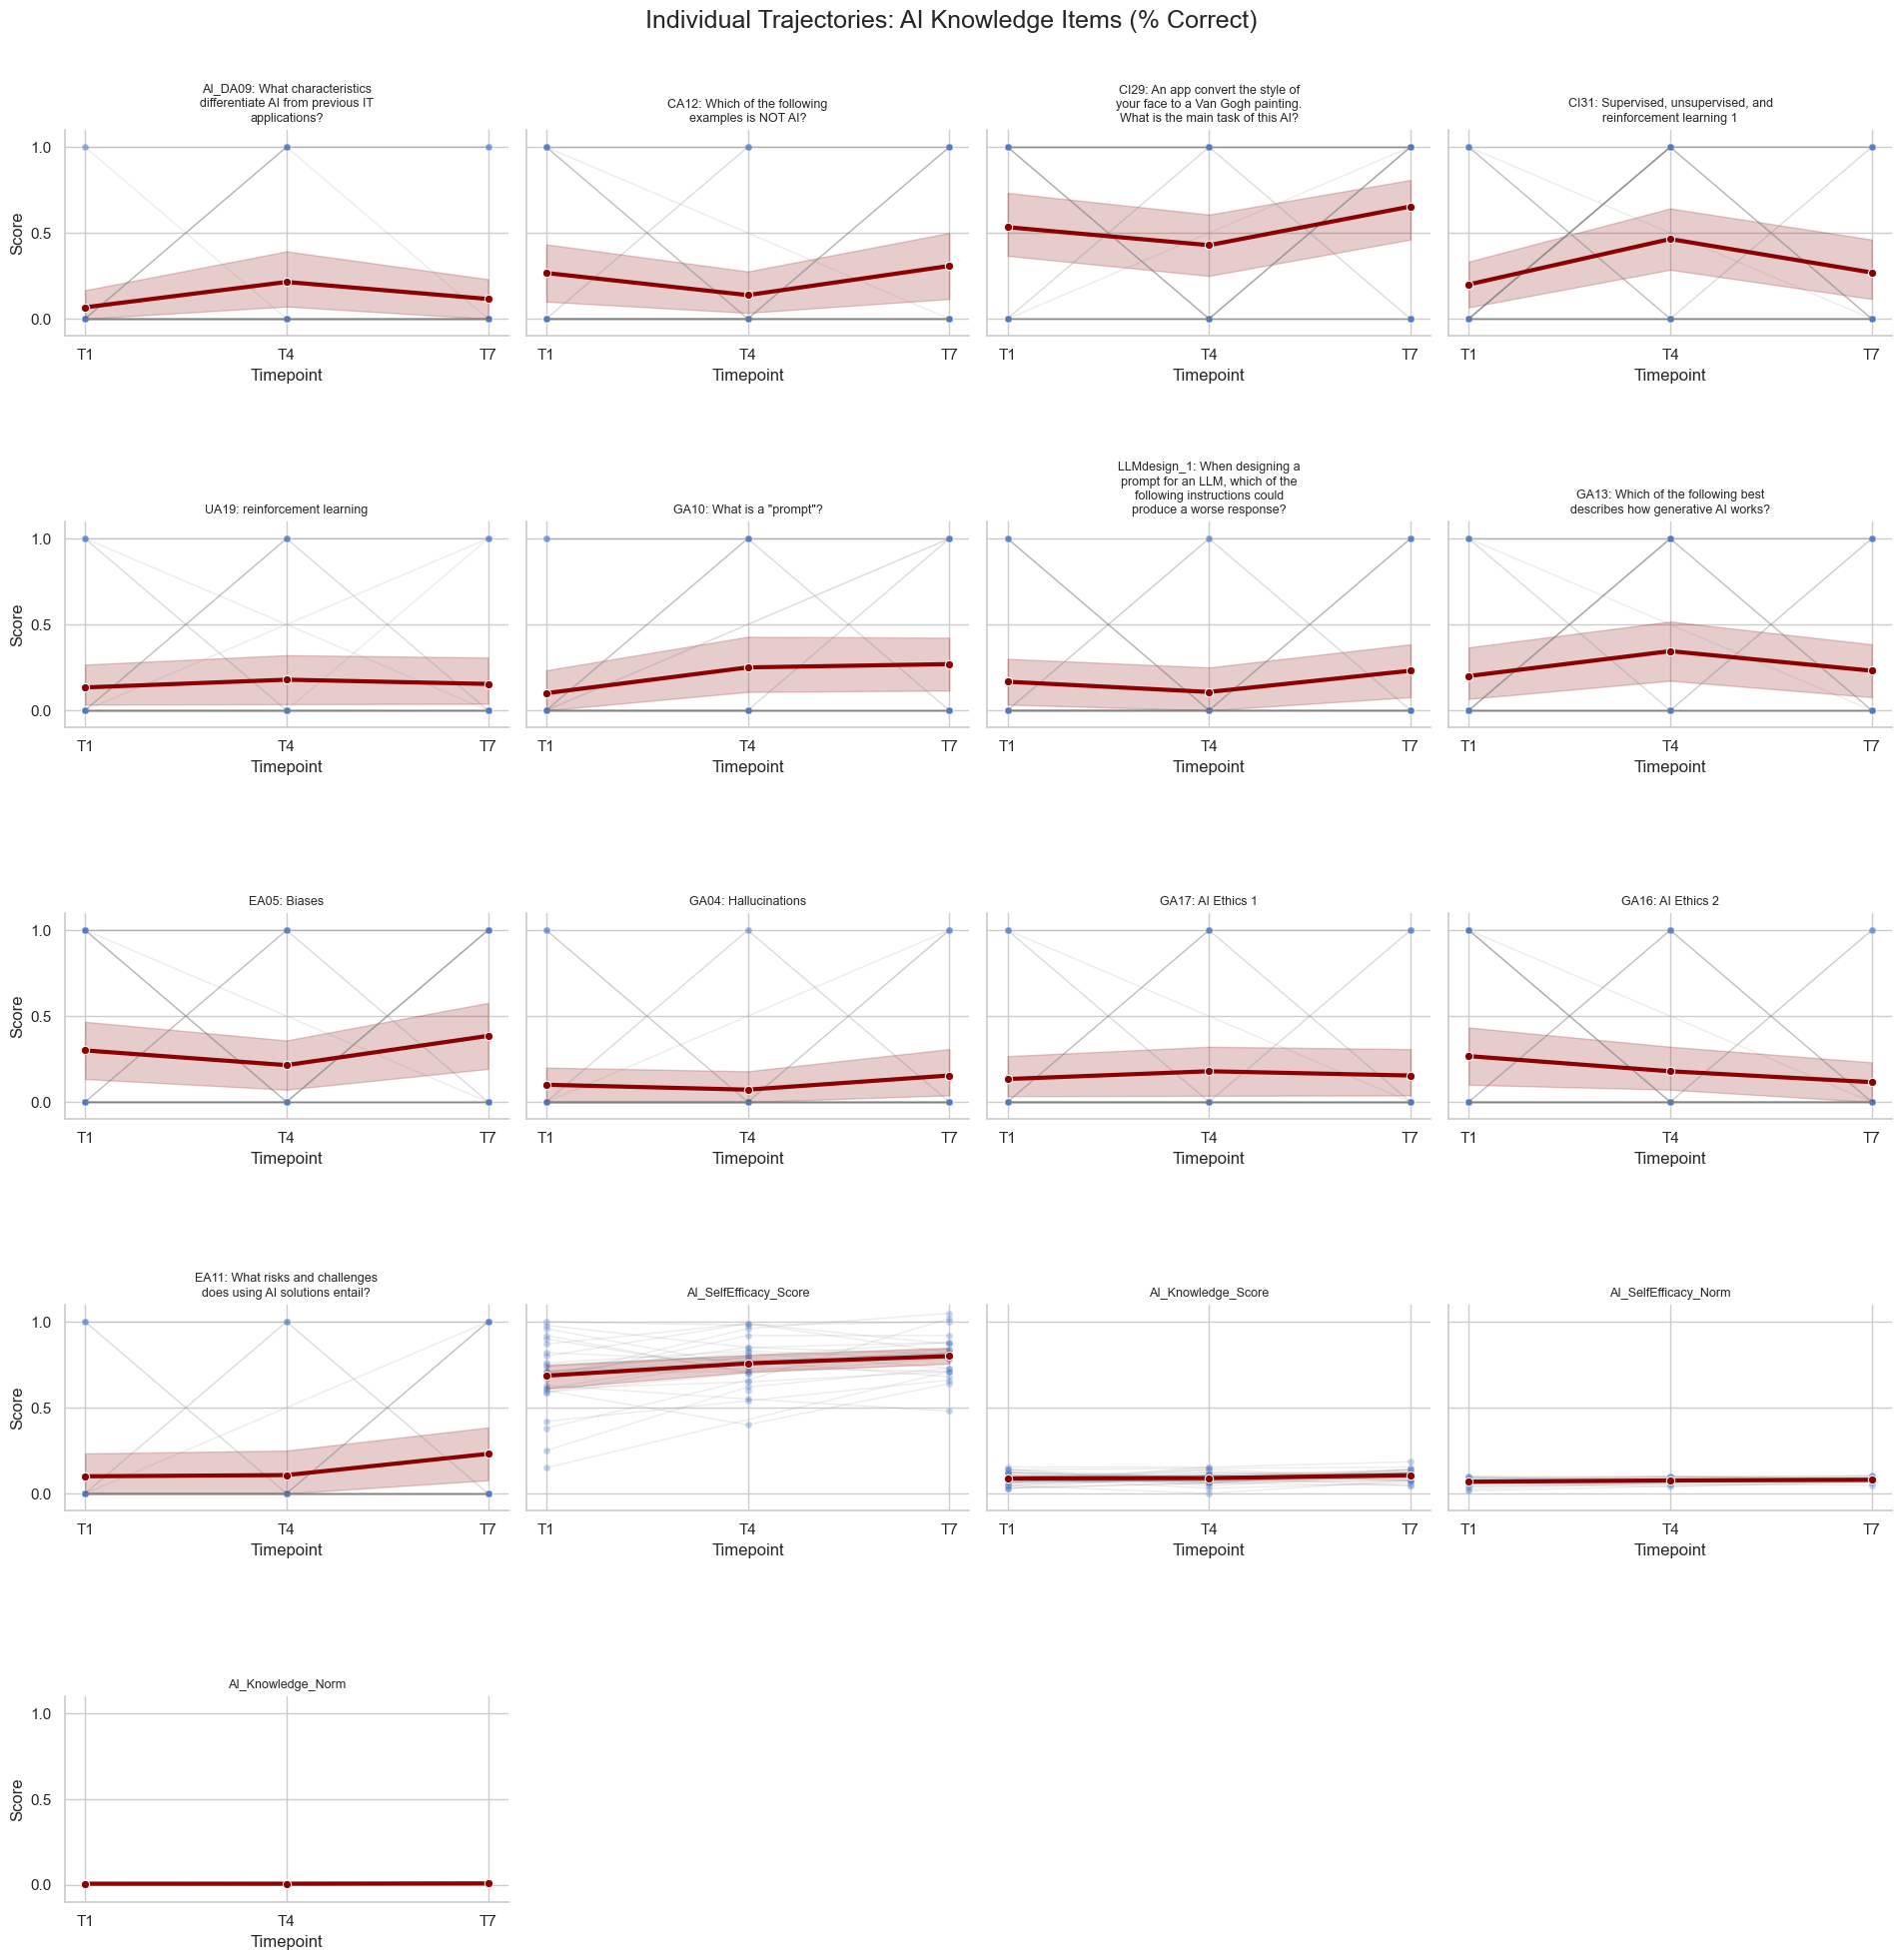

In [26]:
import textwrap

# 1. Identify AI Knowledge columns from our scored dataframe
knowledge_prefixes = ['AI_', 'CA', 'CI', 'UA', 'GA', 'EA', 'LLMdesign']
knowledge_cols = [col for col in df_scored.columns if any(col.startswith(pre) for pre in knowledge_prefixes)]

# 2. Prepare the data
df_knowledge_long = df_scored.melt(
    id_vars=['Timepoint', 'Participant ID'], 
    value_vars=knowledge_cols, 
    var_name='Knowledge_Item', 
    value_name='Score'
)
df_knowledge_long['Timepoint'] = pd.Categorical(df_knowledge_long['Timepoint'], categories=['T1', 'T4', 'T7'], ordered=True)

# 3. Create FacetGrid (4 columns wide for knowledge since there are many items)
g = sns.FacetGrid(df_knowledge_long, col="Knowledge_Item", col_wrap=4, height=4, aspect=1.2, sharey=True, sharex=False)

# 4. Map the lines and points
# Note: For binary 0/1 data, the lines will overlap. Low alpha helps see density.
g.map_dataframe(
    sns.lineplot, 
    x="Timepoint", 
    y="Score", 
    units="Participant ID", 
    estimator=None, 
    color="gray", 
    alpha=0.15, 
    linewidth=1
)

# Individual points (slightly transparent)
g.map_dataframe(sns.scatterplot, x="Timepoint", y="Score", alpha=0.3, s=25)

# Bold red line for the % of students who got it right (the mean)
g.map_dataframe(
    sns.lineplot, 
    x="Timepoint", 
    y="Score", 
    color="darkred", 
    linewidth=3, 
    marker='o', 
    label="Percent Correct"
)

# 5. Fix titles and labels
for ax, title in zip(g.axes.flat, df_knowledge_long['Knowledge_Item'].unique()):
    # Wrap long question text
    wrapped_title = "\n".join(textwrap.wrap(title, width=35))
    ax.set_title(wrapped_title, fontsize=9)
    
    # Force X-labels and set Y-range to 0-1 for clarity
    ax.tick_params(labelbottom=True)
    ax.set_xlabel('Timepoint')
    ax.set_ylim(-0.1, 1.1) 
    ax.set_yticks([0, 0.5, 1])

# 6. Final adjustments
plt.subplots_adjust(top=0.92, hspace=0.9) 
g.fig.suptitle('Individual Trajectories: AI Knowledge Items (% Correct)', fontsize=18)

plt.show()

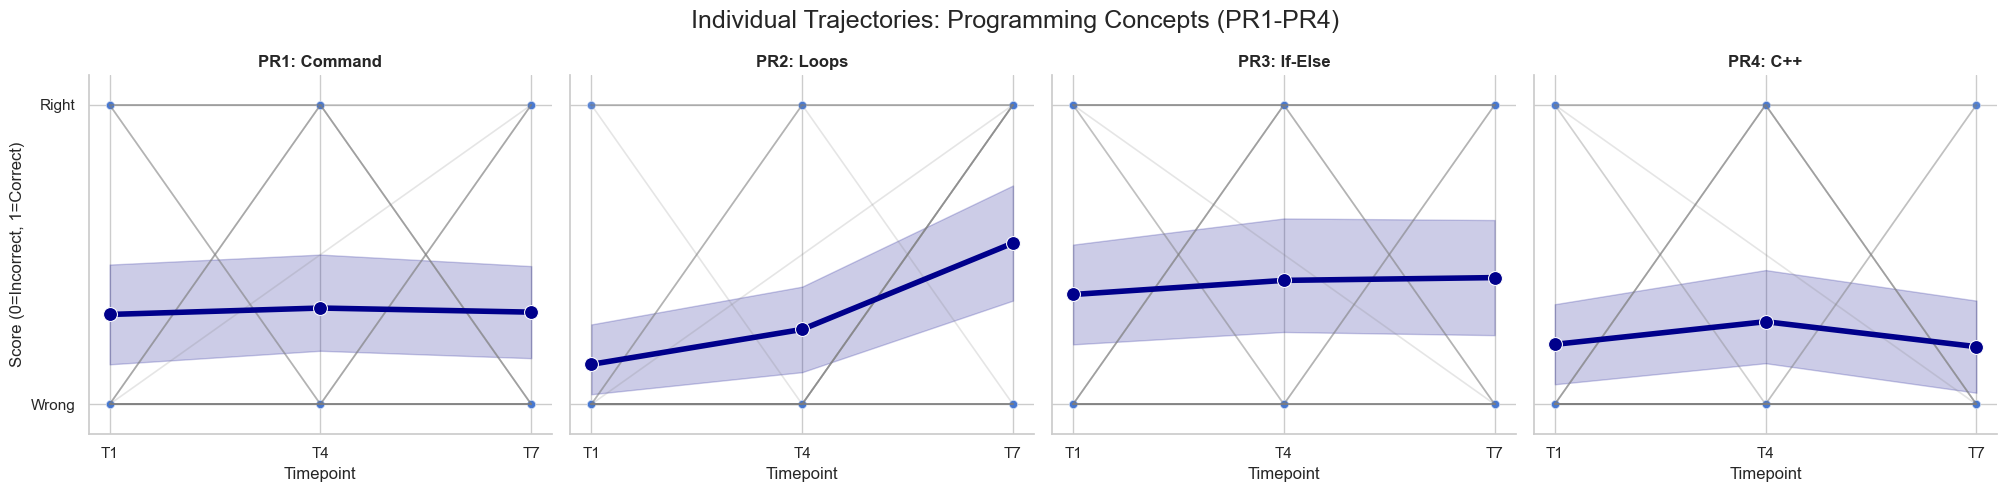

In [28]:
import textwrap

# 1. Define Programming items and their readable names
pr_cols = [col for col in df_scored.columns if col.startswith('PR')]
pr_mapping = {
    'PR1': 'PR1: Command',
    'PR2': 'PR2: Loops',
    'PR3': 'PR3: If-Else',
    'PR4': 'PR4: C++'
}

# 2. Prepare the data
df_pr_long = df_scored.melt(
    id_vars=['Timepoint', 'Participant ID'], 
    value_vars=pr_cols, 
    var_name='PR_Item', 
    value_name='Score'
)

# Replace item names with readable names for the graph
df_pr_long['PR_Item_Label'] = df_pr_long['PR_Item'].map(pr_mapping)
df_pr_long['Timepoint'] = pd.Categorical(df_pr_long['Timepoint'], categories=['T1', 'T4', 'T7'], ordered=True)

# 3. Create FacetGrid (1 row, 4 columns)
g = sns.FacetGrid(df_pr_long, col="PR_Item_Label", col_wrap=4, height=5, aspect=1.0, sharey=True, sharex=False)

# 4. Map individual student trajectories (Gray Lines)
g.map_dataframe(
    sns.lineplot, 
    x="Timepoint", 
    y="Score", 
    units="Participant ID", 
    estimator=None, 
    color="gray", 
    alpha=0.2, 
    linewidth=1.2
)

# Overlay individual points
g.map_dataframe(sns.scatterplot, x="Timepoint", y="Score", alpha=0.4, s=35)

# Overlay Group Mean (Bold blue line for programming)
g.map_dataframe(
    sns.lineplot, 
    x="Timepoint", 
    y="Score", 
    color="darkblue", 
    linewidth=4, 
    marker='o', 
    markersize=10,
    label="Percent Correct"
)

# 5. Fix titles, labels, and axis
for ax, title in zip(g.axes.flat, df_pr_long['PR_Item_Label'].unique()):
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.tick_params(labelbottom=True)
    ax.set_xlabel('Timepoint')
    ax.set_ylabel('Score (0=Incorrect, 1=Correct)')
    
    # Set y-axis strictly to 0-1 for binary data
    ax.set_ylim(-0.1, 1.1)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Wrong', 'Right'])

# 6. Final adjustments
plt.subplots_adjust(top=0.85, hspace=0.4)
g.fig.suptitle('Individual Trajectories: Programming Concepts (PR1-PR4)', fontsize=18)

plt.show()

In [30]:
from scipy.stats import friedmanchisquare, wilcoxon
import pandas as pd

# 1. Prepare Grouped Scores for Stats
# We need a wide format where each row is a Participant and columns are T1, T4, T7
def get_stat_summary(df, cols, group_name):
    # Calculate aggregate score for the group
    df[f'{group_name}_Score'] = df[cols].mean(axis=1)
    
    # Pivot to get T1, T4, T7 in columns for each participant
    pivot = df.pivot(index='Participant ID', columns='Timepoint', values=f'{group_name}_Score')
    
    # We must drop participants who don't have all 3 timepoints for repeated measures
    pivot_clean = pivot.dropna()
    
    # Run Friedman Test (across all 3)
    stat_f, p_f = friedmanchisquare(pivot_clean['T1'], pivot_clean['T4'], pivot_clean['T7'])
    
    # Run Wilcoxon (T1 vs T7 specifically)
    stat_w, p_w = wilcoxon(pivot_clean['T1'], pivot_clean['T7'])
    
    return {
        "Group": group_name,
        "N (Complete)": len(pivot_clean),
        "Friedman p-val": p_f,
        "Wilcoxon T1-T7 p-val": p_w,
        "Significant?": "Yes" if p_w < 0.05 else "No"
    }

# 2. Run for Grouped Scores
stats_results = []
stats_results.append(get_stat_summary(df_scored, mails_cols, "AI_Literacy_MAILS"))
stats_results.append(get_stat_summary(df_scored, knowledge_cols, "AI_Knowledge"))

# 3. Run for Individual Knowledge Items
item_stats = []
for col in knowledge_cols:
    try:
        pivot = df_scored.pivot(index='Participant ID', columns='Timepoint', values=col).dropna()
        if len(pivot) > 5: # Only run if we have enough data points
            _, p_w = wilcoxon(pivot['T1'], pivot['T7'])
            item_stats.append({"Item": col, "T1_Mean": pivot['T1'].mean(), "T7_Mean": pivot['T7'].mean(), "p-value": p_w})
    except:
        continue

# Display Results
print("--- Grouped Score Significance ---")
print(pd.DataFrame(stats_results))

print("\n--- Top Significant Individual Items (T1 vs T7) ---")
item_df = pd.DataFrame(item_stats).sort_values('p-value')
print(item_df[item_df['p-value'] < 0.05]) # Show only significant ones

--- Grouped Score Significance ---
               Group  N (Complete)  Friedman p-val  Wilcoxon T1-T7 p-val  \
0  AI_Literacy_MAILS            24        0.003324              0.006343   
1       AI_Knowledge            24        0.123103              0.044708   

  Significant?  
0          Yes  
1          Yes  

--- Top Significant Individual Items (T1 vs T7) ---
                                                 Item   T1_Mean   T7_Mean  \
13                              AI_SelfEfficacy_Score  0.689583  0.802083   
15                               AI_SelfEfficacy_Norm  0.068958  0.080208   
14                                 AI_Knowledge_Score  0.184977  0.244838   
12  EA11: What risks and challenges does using AI ...  0.043478  0.217391   
16                                  AI_Knowledge_Norm  0.007867  0.009441   

     p-value  
13  0.006020  
15  0.006343  
14  0.044708  
12  0.045500  
16  0.047897  


# Stats in R

In [37]:
# 1. Define the items we actually need for stats
mails_cols = [col for col in df_scored.columns if col.startswith('MAILS_')]
knowledge_prefixes = ['AI_', 'CA', 'CI', 'UA', 'GA', 'EA', 'LLMdesign']
knowledge_cols = [col for col in df_scored.columns if any(col.startswith(pre) for pre in knowledge_prefixes)]
pr_cols = [col for col in df_scored.columns if col.startswith('PR')]

# 2. Select ONLY the necessary columns for the transfer
# This avoids the "mixed type" error in columns like 'googled_time'
cols_to_transfer = ['Participant ID', 'Timepoint'] + mails_cols + knowledge_cols + pr_cols
df_for_r = df_scored[cols_to_transfer].copy()

# 3. Transfer to R
%R -i df_for_r

In [39]:
%%R
# Check the actual column names in R
colnames(df_for_r)

 [1] "Participant ID"                                                                                                      
 [2] "Timepoint"                                                                                                           
 [3] "MAILS_1. I can tell if I am dealing with an application based on artificial intelligence. "                          
 [4] "MAILS_2. I can program new applications in the field of ”artificial intelligence”. "                                 
 [5] "MAILS_3. Although there are often new AI applications, I manage to always be ”up-to date”. "                         
 [6] "MAILS_4. I can handle it when interactions with AI frustrate or frighten me "                                        
 [7] "MAILS_5. I can weigh the consequences of using AI for society. "                                                     
 [8] "MAILS_6. I can design new AI applications. "                                                                         
 [9] "MA

In [46]:
%%R
library(dplyr)
library(tidyr)

# Helper function to run the statistics
analyze_learning <- function(data, item_pattern, label) {
  # 1. Identify columns dynamically to avoid "Column not found" errors
  # We find the ID and Timepoint columns even if they have dots/underscores
  id_col <- grep("Participant", names(data), value = TRUE)[1]
  tp_col <- grep("Timepoint", names(data), value = TRUE)[1]
  item_cols <- grep(item_pattern, names(data), value = TRUE)

  if (length(item_cols) == 0) {
    cat("\n[!] No columns found matching pattern:", item_pattern, "for", label, "\n")
    return(NULL)
  }

  # 2. Select and Clean
  df_summary <- data %>%
    select(all_of(c(id_col, tp_col, item_cols))) %>%
    mutate(across(all_of(item_cols), as.numeric)) %>%
    rowwise() %>%
    mutate(Avg_Score = mean(c_across(all_of(item_cols)), na.rm = TRUE)) %>%
    ungroup() %>%
    select(all_of(id_col), all_of(tp_col), Avg_Score) %>%
    # Use the dynamic names for pivoting
    pivot_wider(names_from = !!sym(tp_col), values_from = Avg_Score) %>%
    drop_na(T1, T4, T7)

  n_students <- nrow(df_summary)

  if(n_students < 2) {
    cat("\n[!] Not enough students (N=", n_students, ") with complete data for:", label, "\n")
    return(NULL)
  }

  # 3. Stats
  f_mat <- as.matrix(df_summary[, c("T1", "T4", "T7")])
  f_test <- friedman.test(f_mat)
  w_test <- wilcox.test(df_summary$T1, df_summary$T7, paired = TRUE)

  # 4. Output
  cat("\n==========================================")
  cat("\nRESULTS FOR:", label)
  cat("\n==========================================")
  cat("\nN (Complete trajectories):", n_students)
  cat("\nMean T1:", mean(df_summary$T1), " | Mean T7:", mean(df_summary$T7))
  cat("\n------------------------------------------")
  cat("\nFriedman p-value:", format.pval(f_test$p.value, digits=3))
  cat("\nWilcoxon (T1-T7) p-value:", format.pval(w_test$p.value, digits=3))
  cat("\nSignificant Improvement?", if(w_test$p.value < 0.05) "YES" else "NO")
  cat("\n\n")
}

# Run with the same patterns
analyze_learning(df_for_r, "^MAILS_", "AI Literacy (MAILS)")
analyze_learning(df_for_r, "^(AI_|CA|CI|UA|GA|EA|LLMdesign)", "AI Knowledge")
analyze_learning(df_for_r, "^PR", "Programming (PR)")


RESULTS FOR: AI Literacy (MAILS)
N (Complete trajectories): 24
Mean T1: 6.895833  | Mean T7: 8.020833
------------------------------------------
Friedman p-value: 0.00332
Wilcoxon (T1-T7) p-value: 0.00669
Significant Improvement? YES


RESULTS FOR: AI Knowledge
N (Complete trajectories): 24
Mean T1: 0.5632714  | Mean T7: 0.6846706
------------------------------------------
Friedman p-value: 0.0197
Wilcoxon (T1-T7) p-value: 0.00446
Significant Improvement? YES


RESULTS FOR: Programming (PR)
N (Complete trajectories): 24
Mean T1: 0.1979167  | Mean T7: 0.34375
------------------------------------------
Friedman p-value: 0.0713
Wilcoxon (T1-T7) p-value: 0.0449
Significant Improvement? YES



De plus : Messages d'avis :
1: Dans wilcox.test.default(df_summary$T1, df_summary$T7, paired = TRUE) :
  impossible de calculer la p-value exacte avec des ex-aequos
2: Dans wilcox.test.default(df_summary$T1, df_summary$T7, paired = TRUE) :
  impossible de calculer une p-value exacte avec des zéros
3: Dans wilcox.test.default(df_summary$T1, df_summary$T7, paired = TRUE) :
  impossible de calculer une p-value exacte avec des zéros
4: Dans wilcox.test.default(df_summary$T1, df_summary$T7, paired = TRUE) :
  impossible de calculer la p-value exacte avec des ex-aequos
5: Dans wilcox.test.default(df_summary$T1, df_summary$T7, paired = TRUE) :
  impossible de calculer une p-value exacte avec des zéros
